<a href="https://colab.research.google.com/github/deepakgarkoti20-bit/Plant-Disease-Detection/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Seeding for reproducibility

In [ ]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

Importing the Dependencies

In [ ]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

Data Curation

Upload the kaggle.json file

In [ ]:
!pip install kaggle

In [ ]:
kaggle_credential = json.load(open("kaggle.json"))

In [ ]:
# set up kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credential["username"]
os.environ['KAGGLE_KEY'] = kaggle_credential["key"]

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:18<00:00, 120MB/s]



In [ ]:
!ls

drive  kaggle.json  plantvillage-dataset.zip  sample_data


In [ ]:
# Unzip the downloaded datasets
with ZipFile("plantvillage-dataset.zip", 'r')as zip_ref:
  zip_ref.extractall()

In [ ]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])
print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))

print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Cherry_(including_sour)___healthy', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Common_rust_', 'Blueberry___healthy', 'Tomato___Tomato_mosaic_virus']
38
['Cherry_(including_sour)___healthy', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Common_rust_', 'Blueberry___healthy', 'Tomato___Tomato_mosaic_virus']
38
['Cherry_(including_sour)___healthy', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Common_rust_', 'Blueberry___healthy', 'Tomato___Tomato_mosaic_virus']


Number of classes = 38

In [ ]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['eb3c315d-2ec9-4923-a602-9bce8c2db303___Mt.N.V_HL 6188.JPG', 'c9bc0233-38a5-4104-ae08-fec0501b28f6___Mt.N.V_HL 6068.JPG', 'bd88082c-b059-4087-88f4-b6ba9cbf07aa___Mt.N.V_HL 6124.JPG', '69a50f71-f8ee-4280-ac3e-c1d68e950c2e___Mt.N.V_HL 6165.JPG', 'f2c0965b-9c08-4e34-98e2-fbf310ae2ef8___Mt.N.V_HL 9038.JPG']


Data Preprocessing

In [ ]:
# Dataset path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


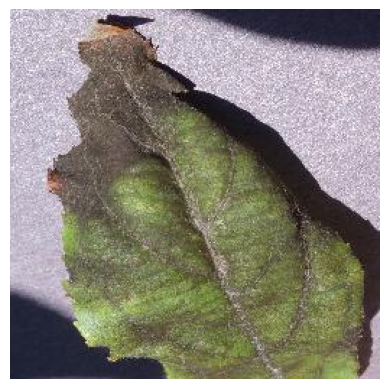

In [ ]:
image_path = '/content/plantvillage dataset/color/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG'

#Read the image
img = mpimg.imread(image_path)

print(img.shape)
#Display the image
plt.imshow(img)
plt.axis('off')
#turn off axis numbers
plt.show()

In [ ]:
#image Parameters
img_size = 224
batch_size = 32

Train Test split

In [ ]:
# Image Data Generators
data_gen = ImageDataGenerator(
rescale=1./255,
 validation_split=0.2
#use 20% of data validation
)

In [ ]:
#Train generator
train_generator = data_gen.flow_from_directory(
base_dir,
target_size=(img_size, img_size),
batch_size=batch_size,
subset='training',
class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [ ]:
#Validation generator
validation_generator = data_gen.flow_from_directory(
base_dir,
target_size=(img_size, img_size),
batch_size=batch_size,
subset='validation',
class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


Convolutional Neural Network

In [ ]:
#model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu' , input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2,2))


model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the Model
model.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
#Training the model
history = model.fit(
  train_generator,
  steps_per_epoch=train_generator.samples // batch_size, #Number of steps per epoch
epochs=5, #Number of epochs
validation_data=validation_generator,
validation_steps=validation_generator.samples // batch_size
#Validation steps
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 74ms/step - accuracy: 0.7444 - loss: 0.9096 - val_accuracy: 0.8415 - val_loss: 0.5049
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 135s 74ms/step - accuracy: 0.9212 - loss: 0.2461 - val_accuracy: 0.8620 - val_loss: 0.4514
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 98s 72ms/step - accuracy: 0.9618 - loss: 0.1184 - val_accuracy: 0.8919 - val_loss: 0.3993
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 99s 73ms/step - accuracy: 0.9742 - loss: 0.0772 - val_accuracy: 0.8412 - val_loss: 0.6750
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 99s 73ms/step - accuracy: 0.9771 - loss: 0.0703 - val_accuracy: 0.8888 - val_loss: 0.5148


In [ ]:
#model evaluation
print("Evaluation model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples //batch_size)
print(f"Validation Accuracy: {val_accuracy *100:.2f}%")

Evaluation model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.8888 - loss: 0.5148
Validation Accuracy: 88.88%


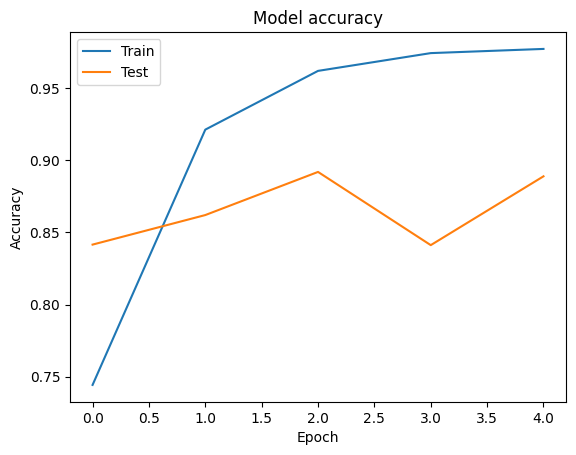

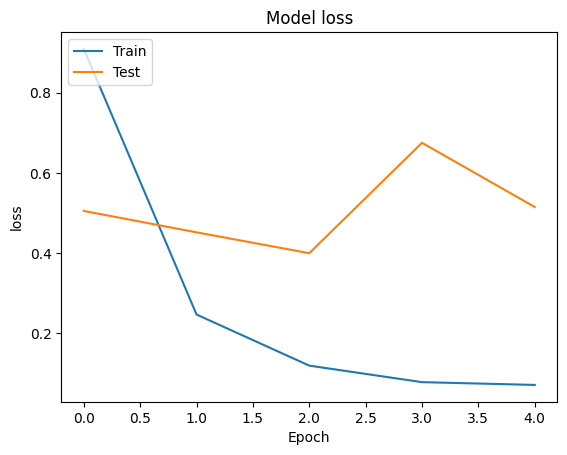

In [ ]:
#plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

#plot training &validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

Building a Predictive System

In [ ]:
 # Function to load and preprocess the image using pillow
def load_and_preprocess_image(image_path, target_size=(224,224)):
    # Load the image
    img = Image.open(image_path)

    # Resize the image
    img = img.resize(target_size)

    # Convert the image to a numpy array
    img_array = np.array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array.astype('float32') / 255.

    return img_array

#Function to predict the class of an image
def predict_image_class(model, image_path, class_indiaces):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions =model.predict(preprocessed_img)
    predicted_class_index =np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [ ]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
#saving the class names aa json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
 # Example Usage
image_path = '/content/plantvillage dataset/color/Corn_(maize)___Common_rust_/RS_Rust 1565.JPG'
#image path
#image path
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step
Predicted Class Name: Corn_(maize)___Common_rust_


In [ ]:
# Save the trained model
model.save('/content/plant_disease_model.keras')
print("Model saved successfully!")

Model saved successfully!
